In [2]:
import retinanalysis as ra
import importlib
importlib.reload(ra.mea_pipeline)
importlib.reload(ra.sta)
import os

Could not connect to DataJoint database: (2003, "Can't connect to MySQL server on '127.0.0.1' ([Errno 111] Connection refused)")


In [3]:
exp_name = '20260415C'
chunk_name = 'chunk3'
datafile_name = ['data026']
str_pkl = os.path.join(ra.settings.QUERY_DIR, f'20260415C/chunk3/kilosort2.5/{exp_name}_{datafile_name[0]}_kilosort2.5.pkl')
pl = ra.MEAPipeline(pkl_file=str_pkl)

Initializing StimBlock for None block None from pickle file
StimBlock loaded from input dict.
Initializing ResponseBlock from pickle file.
ResponseBlock loaded from input dict.
Loading VCD from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/data/sorted/20260415C/data026/kilosort2.5 ...
VCD loaded with 419 cells.

Loading VCD from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/analysis/20260415C/chunk3/kilosort2.5 ...
VCD loaded with 419 cells.

AnalysisChunk loaded from input dict.
MEAPipeline loaded from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/analysis/20260415C/chunk3/kilosort2.5/20260415C_data026_kilosort2.5.pkl


In [ ]:
importlib.reload(ra.sta)
importlib.reload(ra.regen)
importlib.reload(ra.stim)

# pl = ra.mea_pipeline.create_mea_pipeline(exp_name, datafile_name, b_load_fd=True, b_load_vcd=True)
# pl.export_to_pkl(f'/Volumes/data-1/analysis/20260415C/chunk3/kilosort2.5/{exp_name}_{datafile_name[0]}_kilosort2.5.pkl')
# stas = ra.preprocessing.sta.compute_stas_for_chunk(exp_name, chunk_name, datafile_name=datafile_name)
# stas = ra.sta.compute_stas_for_chunk(
stas = ra.sta.compute_stas_for_chunk(
    ra.stim.MEAStimGroup([pl.stim]), ra.MEAResponseGroup([pl.resp]),
    depth=30
)

Regenerating stimulus for epochs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] in block: 5173
Using regeneration function: make_spatial_noise
10


100%|██████████| 12/12 [01:30<00:00,  7.57s/it]


In [4]:
stas.shape

(419, 30, 114, 183, 3)

In [5]:
pl.resp.cell_ids[100]

np.int64(111)

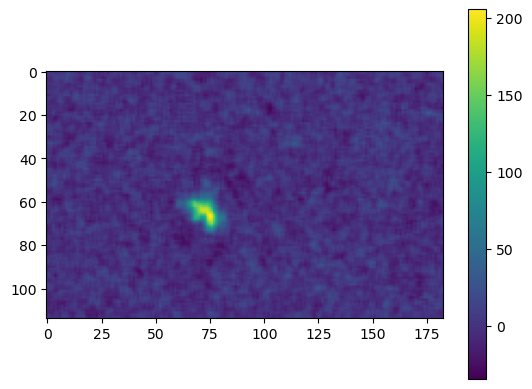

In [8]:
import matplotlib.pyplot as plt
plt.imshow(stas[100, -3, :, :, 0])
plt.colorbar()

In [12]:
import gc
gc.collect()
# Clear GPU memory
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()